# kernelmoments tutorial

This notebook introduces the **kernelmoments** library, which estimates conditional moments using kernel regression. We will:

1. Fit estimators directly to understand the core API.
2. Discuss briefly why scaling helps kernel methods.
3. Use `plot_relationship` for quick one-off plots from NumPy arrays.
4. Use the `Plotter` class for a convenient DataFrame-based workflow.

We'll use cross-sectional stock returns from Yahoo Finance (yfinance) as our running example.

## Setup

```bash
pip install kernelmoments yfinance
```

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from kernelboost.utilities import RankTransformer

from kernelmoments import (
    MeanEstimator,
    VarianceEstimator,
    CovarianceEstimator,
    plot_relationship,
    Plotter,
)

## Data

First, we download daily closing prices for Coca-Cola (KO), PepsiCo (PEP), and the S&P 500, then compute percentage returns.

In [3]:
data = yf.download(["KO", "PEP", "^GSPC"], start="2019-01-01", end="2025-12-31")
returns = data["Close"].pct_change().dropna()
returns.columns = ["KO", "PEP", "SP500"]
returns_df = returns.copy()
returns = returns.values * 100

print(f"Shape: {returns.shape}")
print(f"Columns: KO (0), PEP (1), SP500 (2)")

[*********************100%***********************]  3 of 3 completed

Shape: (1758, 3)
Columns: KO (0), PEP (1), SP500 (2)


## 1. Estimators

The core of kernelmoments consists of estimator classes that follow a scikit-learn-style `fit` / `predict` pattern. Under the hood, each estimator builds a `KernelTree` (from kernelboost) that partitions the data and fits local Nadaraya-Watson kernel regressions with automatic bandwidth selection.

### MeanEstimator: E[Y|X]

Let's start by estimating how the expected KO return varies with the S&P 500 return.

MeanEstimator(fitted)


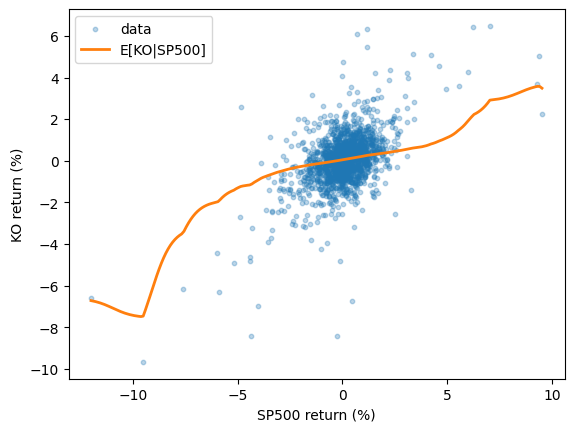

In [4]:
X = returns[:, 2]    # SP500
y = returns[:, 0]    # KO

mean_est = MeanEstimator()
mean_est.fit(X, y)
print(mean_est)  # shows fitted status

# Predict on a grid, then plot:
x_grid = np.linspace(X.min(), X.max(), 200).astype(np.float32)
y_hat = mean_est.predict(x_grid)

fig, ax = plt.subplots()
ax.scatter(X.ravel(), y, alpha=0.3, s=10, label="data")
ax.plot(x_grid, y_hat, color="C1", linewidth=2, label="E[KO|SP500]")
ax.set_xlabel("SP500 return (%)"); ax.set_ylabel("KO return (%)")
ax.legend()

### VarianceEstimator: Var[Y|X]

`VarianceEstimator` uses a two-pass approach (Fan & Yao 1998): first estimate E[Y|X], then regress the squared residuals on X with an independently optimized bandwidth.

Text(0.5, 1.0, 'Conditional variance')

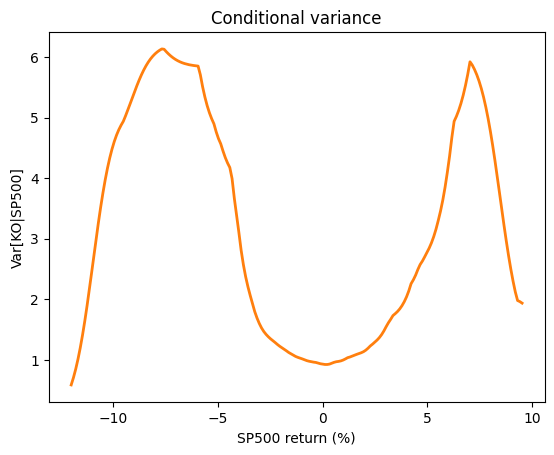

In [5]:
var_est = VarianceEstimator().fit(X, y)
y_var = var_est.predict(x_grid)

fig, ax = plt.subplots()
ax.plot(x_grid, y_var, color="C1", linewidth=2)
ax.set_xlabel("SP500 return (%)"); ax.set_ylabel("Var[KO|SP500]")
ax.set_title("Conditional variance")

### CovarianceEstimator: Cov[Y, Z|X] and Corr[Y, Z|X]

`CovarianceEstimator` uses a three-pass approach (Yin et al. 2010): estimate E[Y|X] and E[Z|X], then regress the product of the Y and Z residuals. For correlation, call `fit_correlation()` after `fit()` and use `predict_correlation()`.

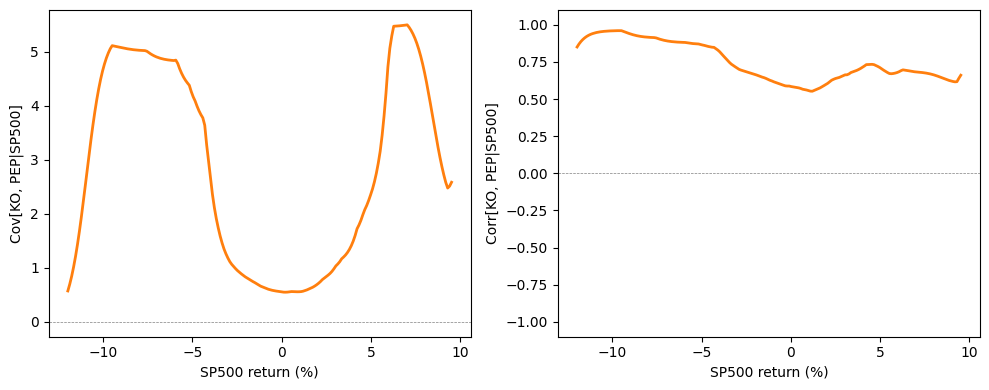

In [6]:
z = returns[:, 1]  # PEP

cov_est = CovarianceEstimator().fit(X, y, z)
cov_est.fit_correlation()

y_cov = cov_est.predict(x_grid)
y_corr = cov_est.predict_correlation(x_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(x_grid, y_cov, color="C1", linewidth=2)
axes[0].axhline(0, color="grey", linewidth=0.5, linestyle="--")
axes[0].set_xlabel("SP500 return (%)"); axes[0].set_ylabel("Cov[KO, PEP|SP500]")

axes[1].plot(x_grid, y_corr, color="C1", linewidth=2)
axes[1].axhline(0, color="grey", linewidth=0.5, linestyle="--")
axes[1].set_ylim(-1.1, 1.1)
axes[1].set_xlabel("SP500 return (%)"); axes[1].set_ylabel("Corr[KO, PEP|SP500]")
fig.tight_layout();

## 2. Why scaling helps

Kernel methods estimate local averages using a bandwidth that controls how much weight nearby points receive. When the conditioning variable has a skewed or heavy-tailed distribution (as stock returns do), the density of observations varies a lot across the range of X. Sparse regions get noisy estimates while dense regions waste resolution.

One way to fix this is to **rank-transform** X before fitting. This spreads observations uniformly, so the kernel can use a single bandwidth effectively everywhere. `kernelboost` provides `RankTransformer` for this purpose. 

Note that by rank-scaling we assume that nearby points are informative about outcomes irrespective of the distance between them. Another option would be to use something like MinMax scaling, which compresses the distribution but preserves distances between points. Also note that after scaling, the x-axis shows ranks rather than original values — we'll see how `Plotter` handles this automatically in the next section.

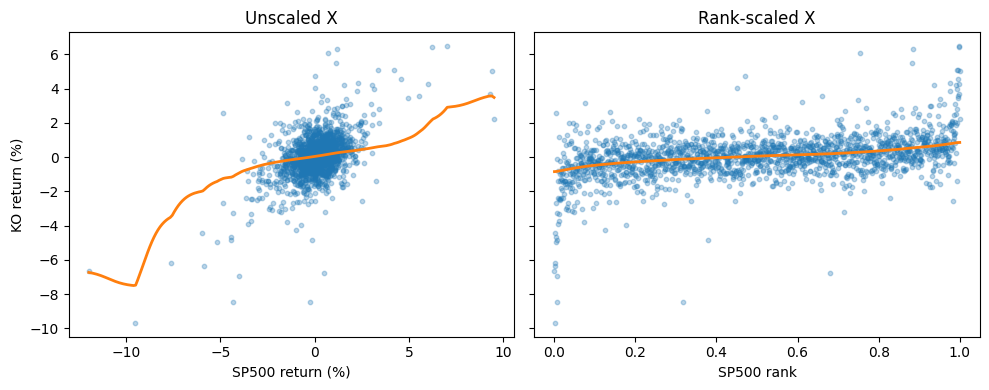

In [12]:
scaler = RankTransformer()
X_scaled = scaler.fit_transform(X.reshape(-1, 1))

mean_est_scaled = MeanEstimator().fit(X_scaled, y)

x_grid_scaled = np.linspace(X_scaled.min(), X_scaled.max(), 200).astype(np.float32)
y_hat_raw = mean_est.predict(x_grid)              # from earlier (unscaled)
y_hat_scaled = mean_est_scaled.predict(x_grid_scaled)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].scatter(X.ravel(), y, alpha=0.3, s=10)
axes[0].plot(x_grid, y_hat_raw, color="C1", linewidth=2)
axes[0].set_title("Unscaled X"); axes[0].set_xlabel("SP500 return (%)")
axes[0].set_ylabel("KO return (%)")

axes[1].scatter(X_scaled.ravel(), y, alpha=0.3, s=10)
axes[1].plot(x_grid_scaled, y_hat_scaled, color="C1", linewidth=2)
axes[1].set_title("Rank-scaled X"); axes[1].set_xlabel("SP500 rank")
fig.tight_layout()

## 3. Quick plots with `plot_relationship`

For one-off exploration with NumPy arrays, `plot_relationship` fits an estimator and plots the result in a single call. Pass `x_plot` to display the original-scale X axis when working with transformed data.

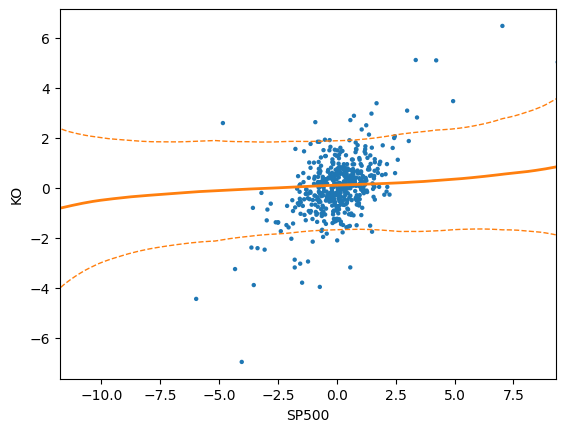

In [9]:
scaled_returns = scaler.fit_transform(returns)

# Conditional mean with prediction bands (±1.96σ)
result = plot_relationship(
    x=scaled_returns[:, 2],
    y=returns[:, 0],
    x_plot=returns[:, 2],   # show original scale on x axis
    moment='mean',
    bands=True,
    x_name='SP500', y_name='KO',
)

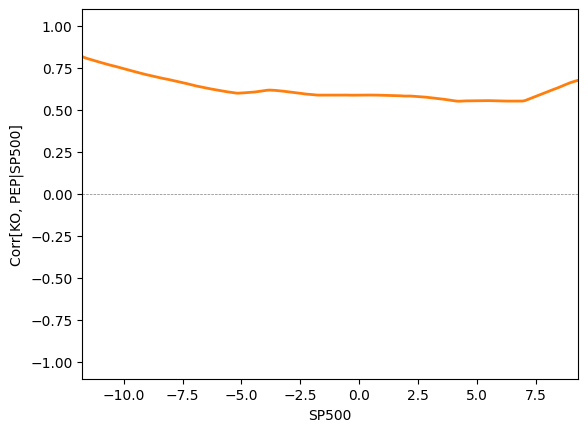

In [10]:
# Conditional correlation
result = plot_relationship(
    x=scaled_returns[:, 2],
    y=returns[:, 0],
    z=returns[:, 1],
    x_plot=returns[:, 2],
    moment='correlation',
    x_name='SP500', y_name='KO', z_name='PEP',
)

`plot_relationship` returns a `PlotResult` dataclass with the figure, axes, prediction grid, predicted values, and the fitted estimator — so you can further customize the plot or reuse the estimator.

In [11]:
print(f"X-values shape: {result.x_values.shape}")
print(f"Y-values shape: {result.y_values.shape}")
print(f"Estimator: {result.estimator}")

X-values shape: (200,)
Y-values shape: (200,)
Estimator: CovarianceEstimator(fitted)


## 4. DataFrame workflow with `Plotter`

For most tasks, `Plotter` is the recommended interface. It takes a pandas (or polars) DataFrame and column names, handles scaling automatically via the optional `x_scaler` argument, caches fitted estimators and displays plots in the original scale of X.

### Setup and first plot

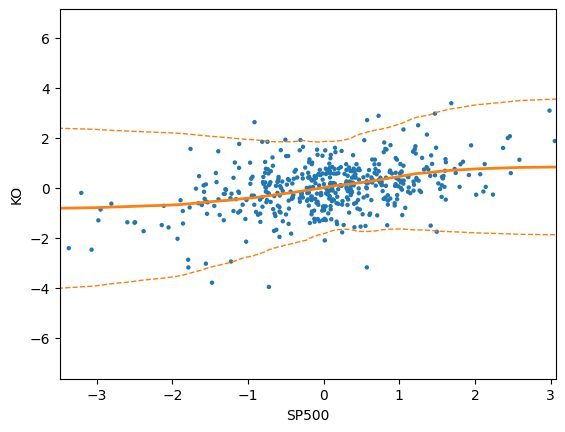

In [13]:
# returns_df is the DataFrame we saved earlier (percentage returns)
returns_df = pd.DataFrame(returns, columns=['KO', 'PEP', 'SP500'])

p = Plotter(returns_df, x_scaler=RankTransformer())
result = p.plot(x='SP500', y='KO', moment='mean', bands=True)

Notice that the x-axis shows SP500 returns in the original scale, even though the estimator was fit on rank-transformed data. The `Plotter` handles the inverse transform automatically. `Plotter` can take in any scaler that has `fit_transform` and `inverse_transform` methods which output NumPy arrays (e.g. sklearn scalers).

### Pre-fitting with `fit()`

When you plan to plot multiple moments for the same variables, call `fit()` first. This pre-fits all relevant estimators (mean, variance, and optionally covariance/correlation) so subsequent `plot()` calls are instant.

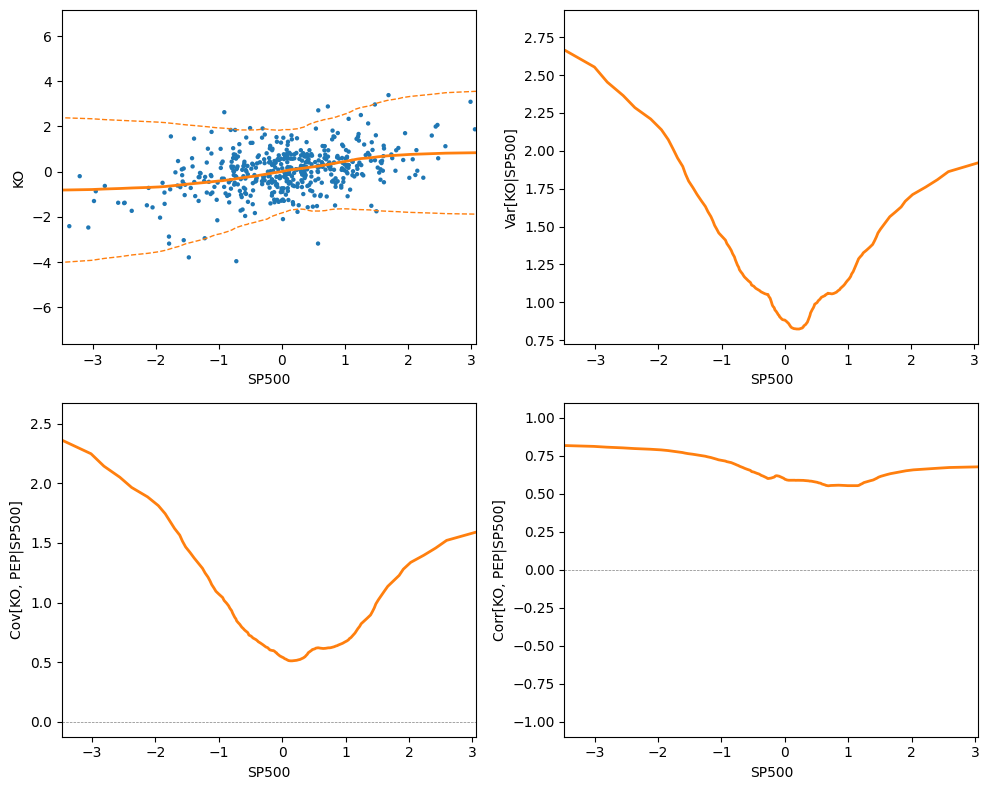

In [14]:
# Pre-fit all moments for KO~SP500 and KO,PEP~SP500
p.fit(x='SP500', y='KO', z='PEP')

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

result_mean = p.plot(x='SP500', y='KO', moment='mean', bands=True, ax=axes[0, 0])
result_variance = p.plot(x='SP500', y='KO', moment='variance', ax=axes[0, 1])
result_covariance = p.plot(x='SP500', y='KO', z='PEP', moment='covariance', ax=axes[1, 0])
result_correlation = p.plot(x='SP500', y='KO', z='PEP', moment='correlation', ax=axes[1, 1])

fig.tight_layout()

### Reading the plots

- **Mean** (top-left): KO returns increase roughly linearly with the market (beta), with prediction bands showing wider uncertainty in the tails.
- **Variance** (top-right): KO is more volatile on days with large market moves in either direction — the classic volatility smile.
- **Covariance** (bottom-left): KO and PEP co-move more strongly during large market moves.
- **Correlation** (bottom-right): This separates the correlation signal from the variance effect. This tells us whether the increased covariance is simply driven by higher volatility or by a genuine increase in correlation.

### Exploring other pairs

Since `Plotter` caches estimators by `(moment, x, y, z)`, you can explore different variable combinations without refitting previous ones.

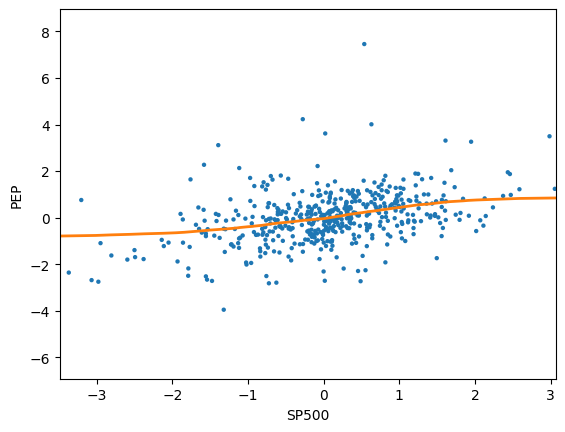

In [15]:
# How does PEP's mean return depend on SP500?
result_pep_mean = p.plot(x='SP500', y='PEP', moment='mean')

## 5. Customizing plots with `PlotStyle`

Both `Plotter` and `plot_relationship` accept a `style` parameter for visual customization. `PlotStyle` is a dataclass — create one with your overrides and pass it in.

In [16]:
from kernelmoments import PlotStyle

style = PlotStyle(
    scatter_color="black",
    scatter_alpha=0.15,
    scatter_size=5,
    line_color="C3",
    line_width=2.5,
    band_linestyle=":",
    x_quantile_trim=0.02,
)

`style` can be passed in either to `plot_relationship` or to `Plotter`. Both Plotter and plot_relationship return PlotResult, so you can customize plots through fig and ax attributes too or by creating your own plots from the x and y values.

## Summary

| Need | Use |
|---|---|
| Full control over fitting and prediction | `MeanEstimator`, `VarianceEstimator`, `CovarianceEstimator` |
| Quick one-off plot from NumPy arrays | `plot_relationship()` |
| DataFrame workflow with caching and automatic scaling | `Plotter` |

All estimators accept `**tree_params` to control the underlying `KernelTree` (bandwidth bounds, depth, GPU, etc.). See the docstrings for details.